# Phase 5 — Règles d'Association

**Input** : `laptop_phase4.csv` (output de la Phase 4)  
**Output** : `association_rules.csv` + `association_rules.json`  

**Colonnes disponibles** : `title`, `brand`, `price`, `platform`, `ram_gb`, `storage_gb`,  
`price_range`, `cluster_kmeans_label`, `is_anomaly`, `anomaly_type`  

Les features items sont : **brand, platform, ram_gb, storage_gb, gamme, anomaly_type**.

**Objectif** : Trouver des liens entre attributs produit et fourchettes de prix.  
Exemples attendus :  
- *"Les laptops HP sur Jumia ont 75% de chance d'être en bas de gamme"*  
- *"16 Go RAM + 512 Go SSD → haut de gamme avec lift=2.1"*

Étapes :
1. Chargement & vérification des colonnes
2. Discrétisation (RAM, stockage)
3. Construction des transactions
4. Apriori — itemsets fréquents + règles
5. FP-Growth — même résultat, plus rapide
6. Filtrage & interprétation des règles → gamme de prix
7. Visualisations
8. Export

## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import json, os, warnings
warnings.filterwarnings('ignore')

# pip install mlxtend
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

INPUT_PATH = '../inputs/laptop_phase4.csv'
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Setup terminé')

✅ Setup terminé


## 1. Chargement & vérification des colonnes

In [4]:
df = pd.read_csv(INPUT_PATH)

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
print()
print('=== Diagnostic des colonnes utilisées en Phase 5 ===')
for col in ['brand', 'platform', 'ram_gb', 'storage_gb', 'price_range',
            'cluster_kmeans_label', 'is_anomaly', 'anomaly_type']:
    if col in df.columns:
        missing = df[col].isna().sum()
        print(f'  ✅ {col:<25}  NaN={missing} ({missing/len(df)*100:.0f}%)')
    else:
        print(f'  ❌ {col:<25}  ABSENTE')
df.head(3)

Shape : (50, 24)
Colonnes : ['title', 'brand', 'price', 'price_usd', 'currency', 'platform', 'ram_gb', 'storage_gb', 'category', 'search_query', 'url', 'scraped_date', 'price_range', 'cluster_kmeans', 'cluster_kmeans_label', 'cluster_dbscan', 'pca_x', 'pca_y', 'iso_score', 'lof_score', 'anomaly_score', 'is_anomaly', 'is_anomaly_soft', 'anomaly_type']

=== Diagnostic des colonnes utilisées en Phase 5 ===
  ✅ brand                      NaN=0 (0%)
  ✅ platform                   NaN=0 (0%)
  ✅ ram_gb                     NaN=12 (24%)
  ✅ storage_gb                 NaN=17 (34%)
  ✅ price_range                NaN=0 (0%)
  ✅ cluster_kmeans_label       NaN=0 (0%)
  ✅ is_anomaly                 NaN=0 (0%)
  ✅ anomaly_type               NaN=0 (0%)


,title,brand,price,price_usd,currency,platform,ram_gb,storage_gb,category,search_query,...,cluster_kmeans_label,cluster_dbscan,pca_x,pca_y,iso_score,lof_score,anomaly_score,is_anomaly,is_anomaly_soft,anomaly_type
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",HP,5799.00,579.90,MAD,jumia,8.0,512.0,electronics,laptop,...,bas_de_gamme,-1,-1.888046,0.074629,-0.537334,1.029518,0.269345,0,0,normal
1,Lenovo ThinkPad X13 Yoga Gen 1 Convertible Lap...,Lenovo,4099.00,409.90,MAD,jumia,16.0,512.0,electronics,laptop,...,bas_de_gamme,0,-1.568627,-0.227634,-0.467459,1.023207,0.161668,0,0,normal
2,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,MSI,39218.93,3921.89,MAD,aliexpress,64.0,2048.0,electronics,laptop,...,haut_de_gamme,-1,4.536421,0.678573,-0.715517,1.887090,0.829744,0,1,normal


## 2. Discrétisation des variables continues

Les algorithmes de règles d'association travaillent sur des **items catégoriels** (vrai/faux).  
On convertit `ram_gb` et `storage_gb` (numériques) en catégories lisibles.  
Les NaN sont simplement **omis** de la transaction (pas d'imputation ici).

In [5]:
# -------------------------------------------------------
# 2.1  Gamme de prix
# -------------------------------------------------------
# On préfère cluster_kmeans_label (Phase 3, basée sur les données)
# sinon on replie sur price_range (Phase 2, basée sur Q1/Q3)
if 'cluster_kmeans_label' in df.columns and df['cluster_kmeans_label'].notna().sum() > 0:
    df['gamme'] = df['cluster_kmeans_label']
    print('→ Gamme : cluster_kmeans_label (K-Means Phase 3)')
else:
    df['gamme'] = df['price_range']
    print('→ Gamme : price_range (Q1/Q3 Phase 2)')

print('Répartition des gammes :')
print(df['gamme'].value_counts())

→ Gamme : cluster_kmeans_label (K-Means Phase 3)
Répartition des gammes :
gamme
bas_de_gamme       35
milieu_de_gamme    10
haut_de_gamme       5
Name: count, dtype: int64


In [6]:
# -------------------------------------------------------
# 2.2  Discrétisation RAM
# -------------------------------------------------------
def discretize_ram(r):
    if pd.isna(r):  return None          # omis de la transaction
    elif r <= 4:    return 'ram_4go'
    elif r <= 8:    return 'ram_8go'
    elif r <= 16:   return 'ram_16go'
    else:           return 'ram_32go+'

df['ram_cat'] = df['ram_gb'].apply(discretize_ram)

print('Distribution ram_cat :')
print(df['ram_cat'].value_counts(dropna=False))

Distribution ram_cat :
ram_cat
ram_32go+    19
ram_16go     16
NaN          12
ram_8go       2
ram_4go       1
Name: count, dtype: int64


In [7]:
# -------------------------------------------------------
# 2.3  Discrétisation Stockage
# -------------------------------------------------------
def discretize_storage(s):
    if pd.isna(s):   return None         # omis de la transaction
    elif s <= 256:   return 'ssd_256go'
    elif s <= 512:   return 'ssd_512go'
    elif s <= 1024:  return 'ssd_1to'
    else:            return 'ssd_2to+'

df['storage_cat'] = df['storage_gb'].apply(discretize_storage)

print('Distribution storage_cat :')
print(df['storage_cat'].value_counts(dropna=False))

Distribution storage_cat :
storage_cat
NaN          17
ssd_1to      13
ssd_512go    11
ssd_2to+      8
ssd_256go     1
Name: count, dtype: int64


In [8]:
# -------------------------------------------------------
# 2.4  Nettoyage brand et platform
# -------------------------------------------------------
df['brand_item']    = 'brand_'    + df['brand'].str.lower().str.strip().str.replace(' ', '_')
df['platform_item'] = 'platform_' + df['platform'].str.lower().str.strip()

# -------------------------------------------------------
# 2.5  Flag anomalie (issu de la Phase 4)
# -------------------------------------------------------
if 'anomaly_type' in df.columns:
    df['anomaly_item'] = df['anomaly_type']   # 'normal', 'prix_suspect_bas', 'prix_suspect_haut'
elif 'is_anomaly' in df.columns:
    df['anomaly_item'] = df['is_anomaly'].map({1: 'is_anomaly', 0: 'is_normal'})
else:
    df['anomaly_item'] = 'is_normal'

print('Distribution anomaly_item :')
print(df['anomaly_item'].value_counts())

Distribution anomaly_item :
anomaly_item
normal               47
prix_suspect_haut     2
prix_suspect_bas      1
Name: count, dtype: int64


## 3. Construction des transactions

Chaque ligne = un produit.  
Chaque transaction = la liste des items présents pour ce produit.  
Les `None` (ram_cat ou storage_cat manquants) sont simplement exclus.

In [9]:
def build_transaction(row):
    items = [
        row['brand_item'],
        row['platform_item'],
        row['gamme'],
        row['anomaly_item'],
    ]
    if row['ram_cat'] is not None:
        items.append(row['ram_cat'])
    if row['storage_cat'] is not None:
        items.append(row['storage_cat'])
    return [i for i in items if pd.notna(i)]

transactions = df.apply(build_transaction, axis=1).tolist()

lengths = [len(t) for t in transactions]
print(f'Nombre de transactions : {len(transactions)}')
print(f'Taille moyenne         : {np.mean(lengths):.2f} items/transaction')
print(f'Taille min / max       : {min(lengths)} / {max(lengths)}')
print()
print('Exemples de transactions :')
for t in transactions[:3]:
    print(' ', t)

Nombre de transactions : 50
Taille moyenne         : 5.42 items/transaction
Taille min / max       : 4 / 6

Exemples de transactions :
  ['brand_hp', 'platform_jumia', 'bas_de_gamme', 'normal', 'ram_8go', 'ssd_512go']
  ['brand_lenovo', 'platform_jumia', 'bas_de_gamme', 'normal', 'ram_16go', 'ssd_512go']
  ['brand_msi', 'platform_aliexpress', 'haut_de_gamme', 'normal', 'ram_32go+', 'ssd_2to+']


In [10]:
# Encodage one-hot avec TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Matrice transactionnelle : {df_encoded.shape}')
print(f'Nombre d\'items uniques   : {len(te.columns_)}')
print(f'Densité                  : {df_encoded.values.mean()*100:.1f}%')
print()
print('Items présents :')
print(sorted(te.columns_))

Matrice transactionnelle : (50, 25)
Nombre d'items uniques   : 25
Densité                  : 21.7%

Items présents :
['bas_de_gamme', 'brand_acer', 'brand_gpd', 'brand_honor', 'brand_hp', 'brand_huawei', 'brand_lenovo', 'brand_msi', 'brand_other', 'brand_xiaomi', 'haut_de_gamme', 'milieu_de_gamme', 'normal', 'platform_aliexpress', 'platform_jumia', 'prix_suspect_bas', 'prix_suspect_haut', 'ram_16go', 'ram_32go+', 'ram_4go', 'ram_8go', 'ssd_1to', 'ssd_256go', 'ssd_2to+', 'ssd_512go']


## 4. Apriori — Itemsets fréquents + Règles

Métriques :
- **Support** : fréquence de l'itemset (`P(A ∪ B)`)
- **Confiance** : probabilité conditionnelle `P(B|A)`
- **Lift** : gain vs indépendance — **lift > 1** = association réelle

In [11]:
MIN_SUPPORT    = 0.05   # 5% des transactions minimum
MIN_CONFIDENCE = 0.50   # 50% de confiance minimum
MIN_LIFT       = 1.2    # lift > 1.2 pour filtrer les associations triviales

print(f'Paramètres : support≥{MIN_SUPPORT}, confiance≥{MIN_CONFIDENCE}, lift≥{MIN_LIFT}')
print()
print('Calcul des itemsets fréquents (Apriori)...')

frequent_itemsets_apriori = apriori(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4
)
frequent_itemsets_apriori['length'] = frequent_itemsets_apriori['itemsets'].apply(len)

print(f'Itemsets fréquents : {len(frequent_itemsets_apriori)}')
print(frequent_itemsets_apriori['length'].value_counts().sort_index().rename('count par taille'))

if len(frequent_itemsets_apriori) < 10:
    print('\n⚠ Peu d\'itemsets — essaie MIN_SUPPORT = 0.03 ou 0.02')

Paramètres : support≥0.05, confiance≥0.5, lift≥1.2

Calcul des itemsets fréquents (Apriori)...
Itemsets fréquents : 219
length
1    17
2    59
3    84
4    59
Name: count par taille, dtype: int64


In [12]:
rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric='lift',
    min_threshold=MIN_LIFT
)
rules_apriori = rules_apriori[rules_apriori['confidence'] >= MIN_CONFIDENCE]
rules_apriori = rules_apriori.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Règles Apriori : {len(rules_apriori)}')
rules_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Règles Apriori : 409


,antecedents,consequents,support,confidence,lift
0,"frozenset({brand_honor, ram_32go+})","frozenset({bas_de_gamme, ssd_2to+})",0.06,1.00,10.000000
1,"frozenset({bas_de_gamme, ssd_2to+})","frozenset({brand_honor, ram_32go+})",0.06,0.60,10.000000
2,"frozenset({brand_honor, ram_32go+})","frozenset({ssd_2to+, normal})",0.06,1.00,8.333333
3,"frozenset({ssd_2to+, normal})","frozenset({brand_honor, ram_32go+})",0.06,0.50,8.333333
4,"frozenset({ssd_2to+, normal})","frozenset({bas_de_gamme, brand_honor})",0.06,0.50,8.333333
5,"frozenset({bas_de_gamme, brand_honor})","frozenset({ssd_2to+, normal})",0.06,1.00,8.333333
6,"frozenset({bas_de_gamme, ram_32go+, ssd_2to+})",frozenset({brand_honor}),0.06,0.75,7.500000
7,frozenset({brand_honor}),"frozenset({bas_de_gamme, ram_32go+, ssd_2to+})",0.06,0.60,7.500000
8,"frozenset({bas_de_gamme, brand_honor})","frozenset({ram_32go+, ssd_2to+})",0.06,1.00,7.142857
9,"frozenset({brand_honor, ram_32go+})","frozenset({platform_aliexpress, ssd_2to+})",0.06,1.00,6.250000


## 5. FP-Growth — Alternative plus rapide

FP-Growth construit un arbre compact (FP-Tree) sans générer de candidats intermédiaires.  
Il produit **exactement les mêmes règles** qu'Apriori mais plus vite sur les grands datasets.

In [13]:
print('Calcul des itemsets fréquents (FP-Growth)...')

frequent_itemsets_fp = fpgrowth(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4
)
frequent_itemsets_fp['length'] = frequent_itemsets_fp['itemsets'].apply(len)

rules_fp = association_rules(
    frequent_itemsets_fp,
    metric='lift',
    min_threshold=MIN_LIFT
)
rules_fp = rules_fp[rules_fp['confidence'] >= MIN_CONFIDENCE]
rules_fp = rules_fp.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Itemsets FP-Growth : {len(frequent_itemsets_fp)}')
print(f'Règles FP-Growth   : {len(rules_fp)}')
print(f'Résultats identiques à Apriori : {len(rules_apriori) == len(rules_fp)}')

Calcul des itemsets fréquents (FP-Growth)...
Itemsets FP-Growth : 219
Règles FP-Growth   : 409
Résultats identiques à Apriori : True


In [14]:
# On travaille sur FP-Growth pour la suite
rules = rules_fp.copy()

rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules['rule_str'] = rules['antecedents_str'] + '  →  ' + rules['consequents_str']

print(f'Total règles retenues : {len(rules)}')
print()
print(rules[['rule_str', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

Total règles retenues : 409

                                                   rule_str  support  confidence      lift
          bas_de_gamme, ssd_2to+  →  brand_honor, ram_32go+     0.06        0.60 10.000000
          brand_honor, ram_32go+  →  bas_de_gamme, ssd_2to+     0.06        1.00 10.000000
                brand_honor, ram_32go+  →  normal, ssd_2to+     0.06        1.00  8.333333
                normal, ssd_2to+  →  brand_honor, ram_32go+     0.06        0.50  8.333333
             bas_de_gamme, brand_honor  →  normal, ssd_2to+     0.06        1.00  8.333333
             normal, ssd_2to+  →  bas_de_gamme, brand_honor     0.06        0.50  8.333333
          brand_honor  →  bas_de_gamme, ram_32go+, ssd_2to+     0.06        0.60  7.500000
          bas_de_gamme, ram_32go+, ssd_2to+  →  brand_honor     0.06        0.75  7.500000
          bas_de_gamme, brand_honor  →  ram_32go+, ssd_2to+     0.06        1.00  7.142857
                        brand_honor, ram_32go+  →  ssd_2to+  

## 6. Filtrage & Interprétation

On isole les règles dont le **conséquent est une gamme de prix** (les plus utiles pour le dashboard).

In [15]:
GAMME_ITEMS = {'bas_de_gamme', 'milieu_de_gamme', 'haut_de_gamme'}

rules_gamme = rules[
    rules['consequents'].apply(lambda x: bool(x & GAMME_ITEMS))
].copy().sort_values(['lift', 'confidence'], ascending=False).reset_index(drop=True)

print(f'Règles avec conséquent = gamme de prix : {len(rules_gamme)}')
print()
print(rules_gamme[['rule_str', 'support', 'confidence', 'lift']].head(20).to_string(index=False))

Règles avec conséquent = gamme de prix : 149

                                                     rule_str  support  confidence      lift
            brand_honor, ram_32go+  →  bas_de_gamme, ssd_2to+     0.06        1.00 10.000000
               normal, ssd_2to+  →  bas_de_gamme, brand_honor     0.06        0.50  8.333333
            brand_honor  →  bas_de_gamme, ram_32go+, ssd_2to+     0.06        0.60  7.500000
                       brand_honor  →  bas_de_gamme, ssd_2to+     0.06        0.60  6.000000
  brand_honor, platform_aliexpress  →  bas_de_gamme, ssd_2to+     0.06        0.60  6.000000
  brand_honor  →  bas_de_gamme, platform_aliexpress, ssd_2to+     0.06        0.60  6.000000
               brand_honor  →  bas_de_gamme, normal, ssd_2to+     0.06        0.60  6.000000
               brand_honor, normal  →  bas_de_gamme, ssd_2to+     0.06        0.60  6.000000
              brand_acer  →  bas_de_gamme, ram_32go+, ssd_1to     0.06        0.60  4.285714
            brand_honor,

In [16]:
# Affichage lisible par gamme
for gamme in ['haut_de_gamme', 'milieu_de_gamme', 'bas_de_gamme']:
    subset = rules_gamme[rules_gamme['consequents_str'] == gamme].head(5)
    if len(subset) == 0:
        continue
    print(f'\n══ TOP règles → {gamme.upper().replace("_", " ")} ══')
    for _, row in subset.iterrows():
        pct = int(row['confidence'] * 100)
        sup = int(row['support'] * len(df))
        print(f'  SI   [{row["antecedents_str"]}]')
        print(f'  ALORS [{row["consequents_str"]}]  — confiance {pct}%, lift {row["lift"]:.2f}, ~{sup} produits')
        print()


══ TOP règles → BAS DE GAMME ══
  SI   [brand_huawei, platform_aliexpress, ram_16go]
  ALORS [bas_de_gamme]  — confiance 100%, lift 1.43, ~4 produits

  SI   [brand_honor, platform_aliexpress, ram_32go+]
  ALORS [bas_de_gamme]  — confiance 100%, lift 1.43, ~3 produits

  SI   [normal, ssd_512go]
  ALORS [bas_de_gamme]  — confiance 100%, lift 1.43, ~11 produits

  SI   [ram_16go, ssd_512go]
  ALORS [bas_de_gamme]  — confiance 100%, lift 1.43, ~9 produits

  SI   [normal, ram_16go, ssd_512go]
  ALORS [bas_de_gamme]  — confiance 100%, lift 1.43, ~9 produits



In [17]:
# Bonus : règles → anomalie
ANOMALY_ITEMS = {'prix_suspect_bas', 'prix_suspect_haut', 'is_anomaly'}

rules_anomaly = rules[
    rules['consequents'].apply(lambda x: bool(x & ANOMALY_ITEMS))
].copy().sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Règles avec conséquent = anomalie : {len(rules_anomaly)}')
if len(rules_anomaly) > 0:
    print(rules_anomaly[['rule_str', 'support', 'confidence', 'lift']].head(10).to_string(index=False))

Règles avec conséquent = anomalie : 0


## 7. Visualisations

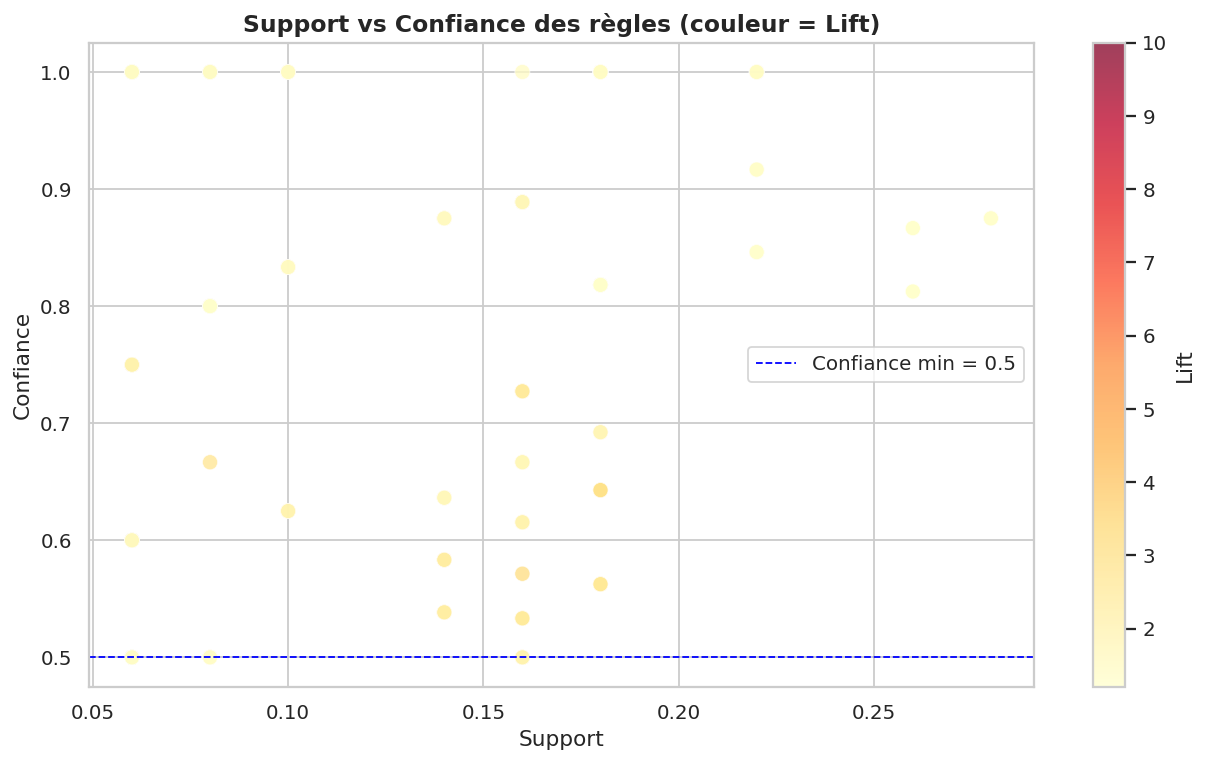

✅ phase5_support_confidence.png


In [18]:
# --- 7.1 Scatter : Support vs Confiance, coloré par Lift ---
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd',
    s=70, alpha=0.75, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.axhline(MIN_CONFIDENCE, color='blue', linestyle='--', linewidth=1,
           label=f'Confiance min = {MIN_CONFIDENCE}')
ax.set_title('Support vs Confiance des règles (couleur = Lift)', fontsize=13, fontweight='bold')
ax.set_xlabel('Support')
ax.set_ylabel('Confiance')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_support_confidence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase5_support_confidence.png')

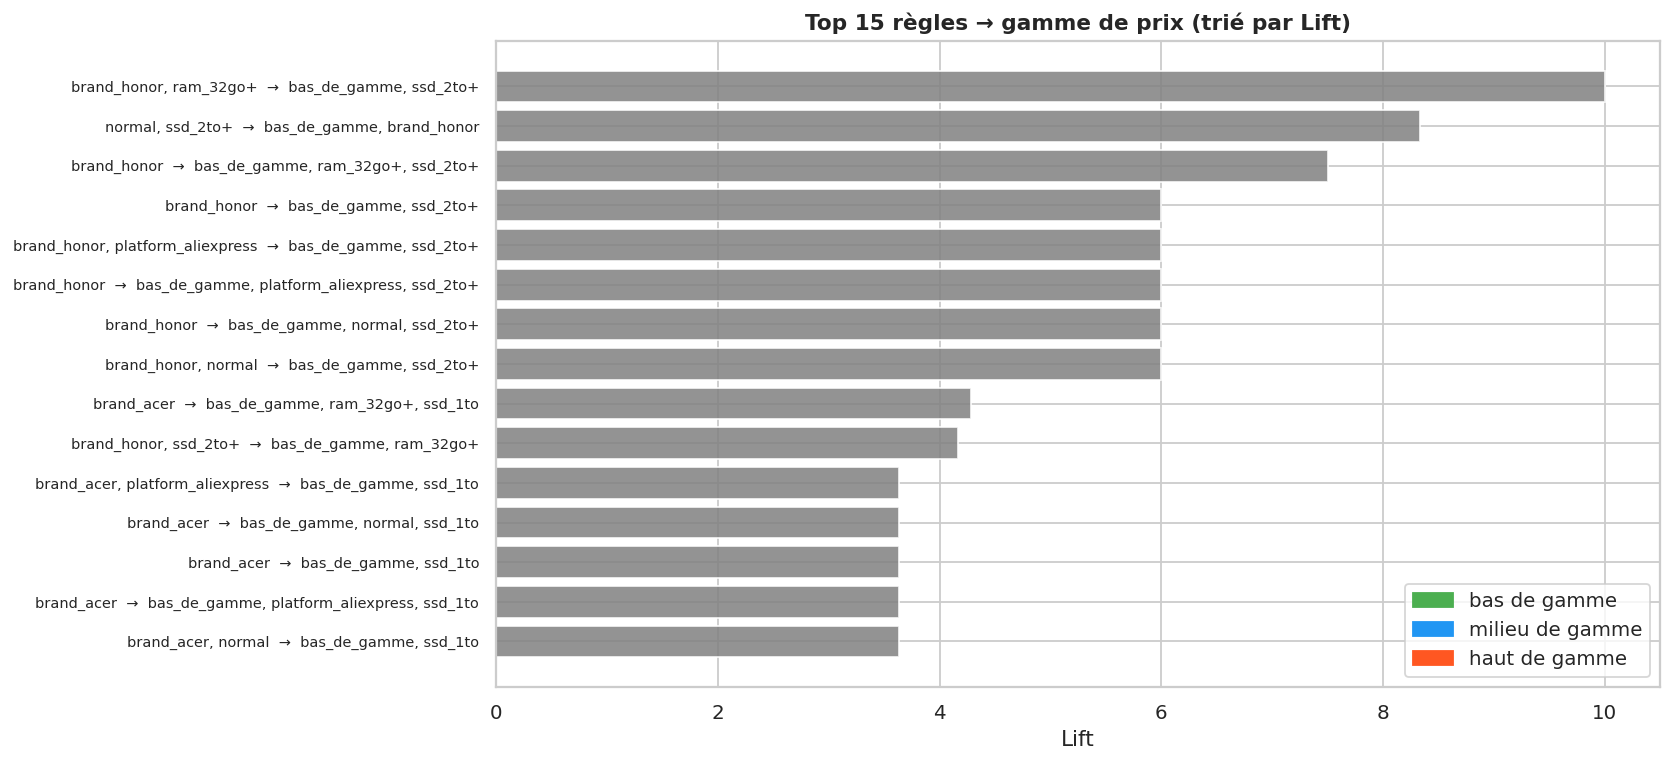

✅ phase5_top_rules_lift.png


In [19]:
# --- 7.2 Barplot horizontal : Top 15 règles → gamme ---
top15 = rules_gamme.head(15)
COLOR_MAP = {
    'bas_de_gamme':    '#4CAF50',
    'milieu_de_gamme': '#2196F3',
    'haut_de_gamme':   '#FF5722'
}
bar_colors = top15['consequents_str'].map(COLOR_MAP).fillna('gray')

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(range(len(top15)), top15['lift'].values, color=bar_colors, alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(
    [f"{r['antecedents_str']}  →  {r['consequents_str']}" for _, r in top15.iterrows()],
    fontsize=8
)
ax.invert_yaxis()
ax.set_xlabel('Lift')
ax.set_title('Top 15 règles → gamme de prix (trié par Lift)', fontsize=12, fontweight='bold')
legend_els = [mpatches.Patch(color=c, label=l.replace('_', ' ')) for l, c in COLOR_MAP.items()]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_top_rules_lift.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase5_top_rules_lift.png')

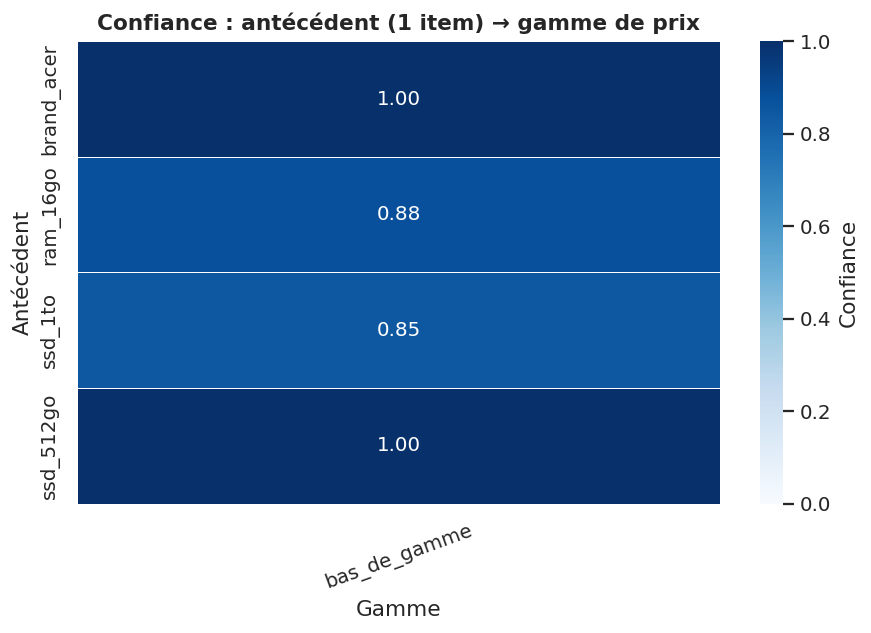

✅ phase5_heatmap_confidence.png


In [20]:
# --- 7.3 Heatmap : confiance par antécédent (1 item) × gamme ---
rules_1ant = rules[
    (rules['antecedents'].apply(len) == 1) &
    (rules['consequents'].apply(lambda x: bool(x & GAMME_ITEMS)))
].copy()

if len(rules_1ant) > 0:
    rules_1ant['ant']  = rules_1ant['antecedents_str']
    rules_1ant['cons'] = rules_1ant['consequents_str']
    pivot = rules_1ant.pivot_table(values='confidence', index='ant', columns='cons', aggfunc='max')
    gamme_cols = [c for c in pivot.columns if c in GAMME_ITEMS]
    pivot = pivot[gamme_cols].dropna(how='all')

    fig, ax = plt.subplots(figsize=(max(7, len(gamme_cols)*3), max(5, len(pivot)*0.5)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues',
                linewidths=0.5, ax=ax, vmin=0, vmax=1,
                cbar_kws={'label': 'Confiance'})
    ax.set_title('Confiance : antécédent (1 item) → gamme de prix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Gamme')
    ax.set_ylabel('Antécédent')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_heatmap_confidence.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ phase5_heatmap_confidence.png')
else:
    print('⚠ Pas assez de règles à 1 antécédent — essaie MIN_SUPPORT = 0.03')

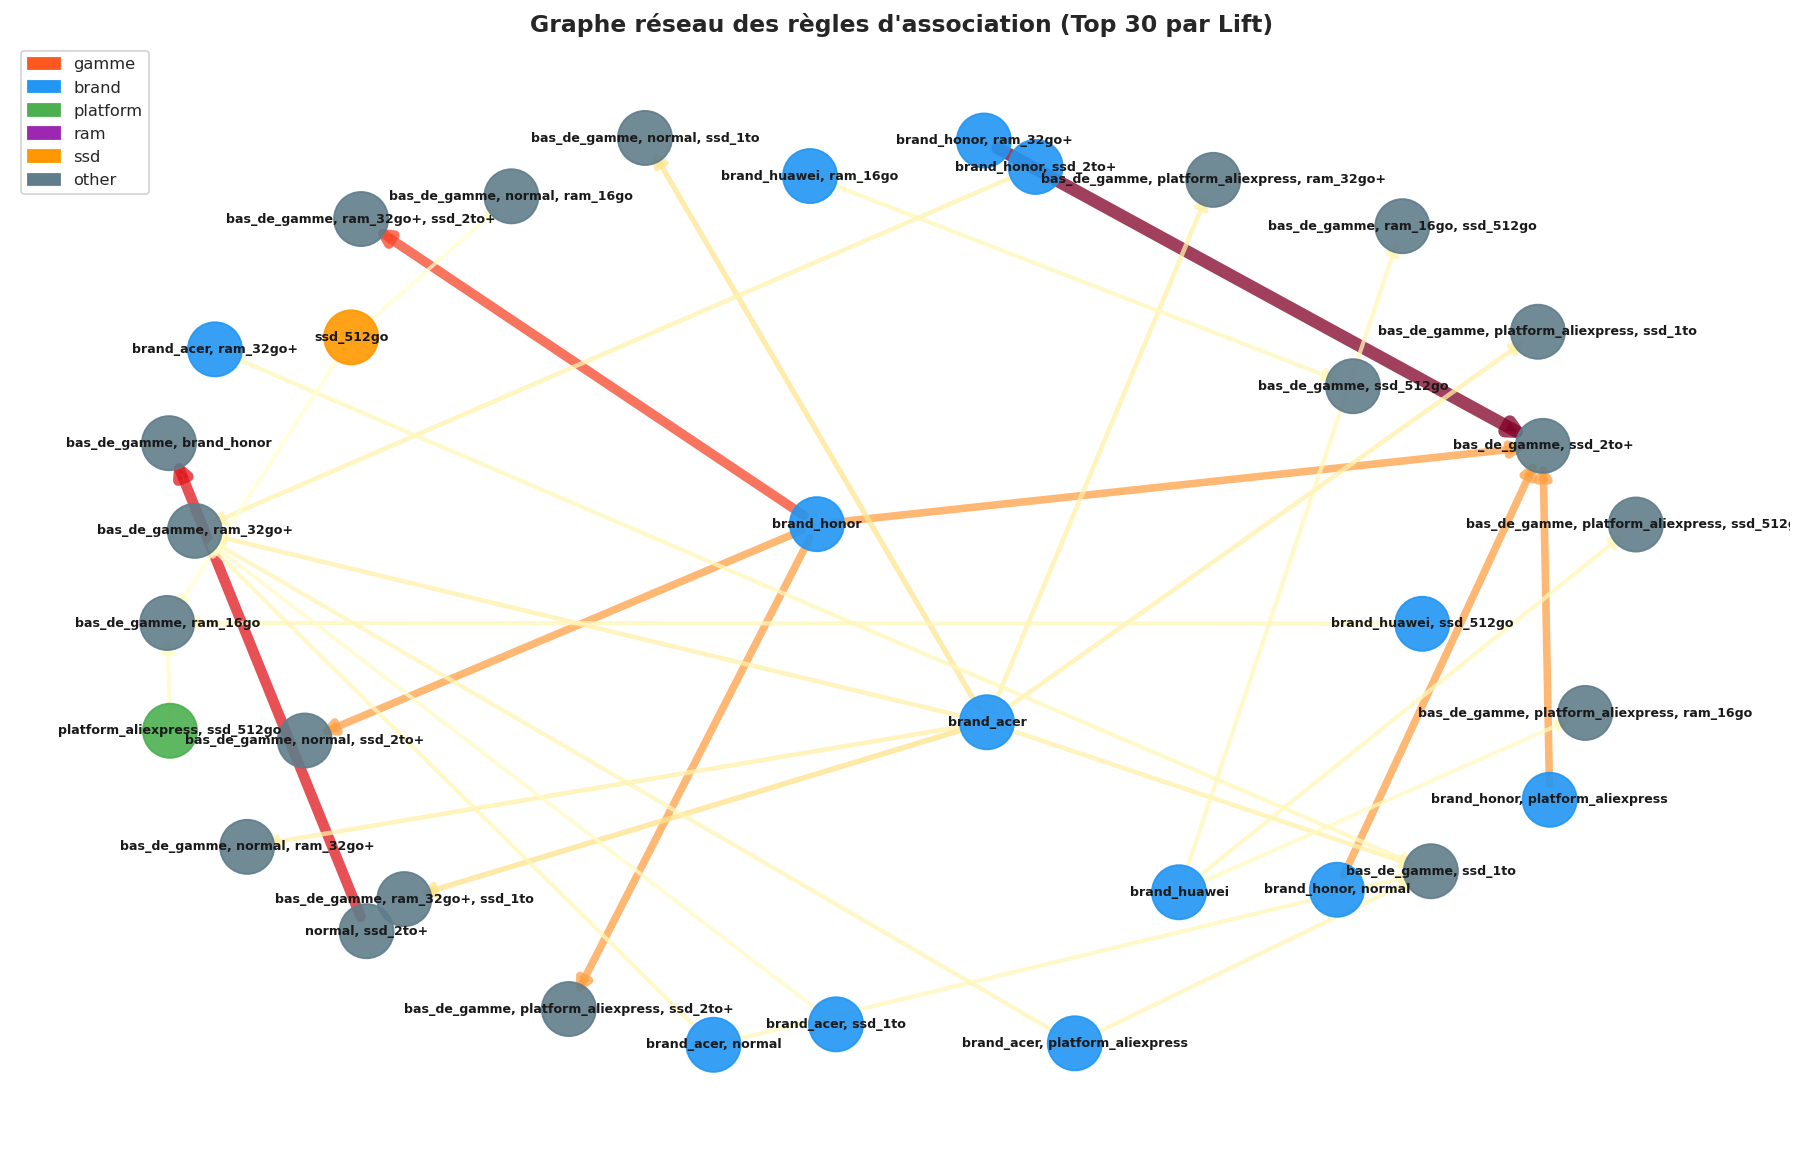

✅ phase5_network_graph.png


In [21]:
# --- 7.4 Graphe réseau des associations (NetworkX) ---
TOP_N = min(30, len(rules_gamme))

G = nx.DiGraph()
edge_lifts = []
for _, row in rules_gamme.head(TOP_N).iterrows():
    G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['lift'])
    edge_lifts.append(row['lift'])

NODE_COLORS = {
    'gamme':    '#FF5722',
    'brand':    '#2196F3',
    'platform': '#4CAF50',
    'ram':      '#9C27B0',
    'ssd':      '#FF9800',
    'other':    '#607D8B',
}

def node_color(n):
    if n in GAMME_ITEMS:           return NODE_COLORS['gamme']
    if n.startswith('brand_'):     return NODE_COLORS['brand']
    if n.startswith('platform_'):  return NODE_COLORS['platform']
    if n.startswith('ram_'):       return NODE_COLORS['ram']
    if n.startswith('ssd_'):       return NODE_COLORS['ssd']
    return NODE_COLORS['other']

colors = [node_color(n) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=900, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos,
    width=[w * 0.7 for w in edge_lifts],
    edge_color=edge_lifts, edge_cmap=plt.cm.YlOrRd,
    alpha=0.75, arrows=True, arrowsize=15, ax=ax
)
legend_els = [mpatches.Patch(color=c, label=l) for l, c in NODE_COLORS.items()]
ax.legend(handles=legend_els, loc='upper left', fontsize=9)
ax.set_title(f'Graphe réseau des règles d\'association (Top {TOP_N} par Lift)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_network_graph.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase5_network_graph.png')

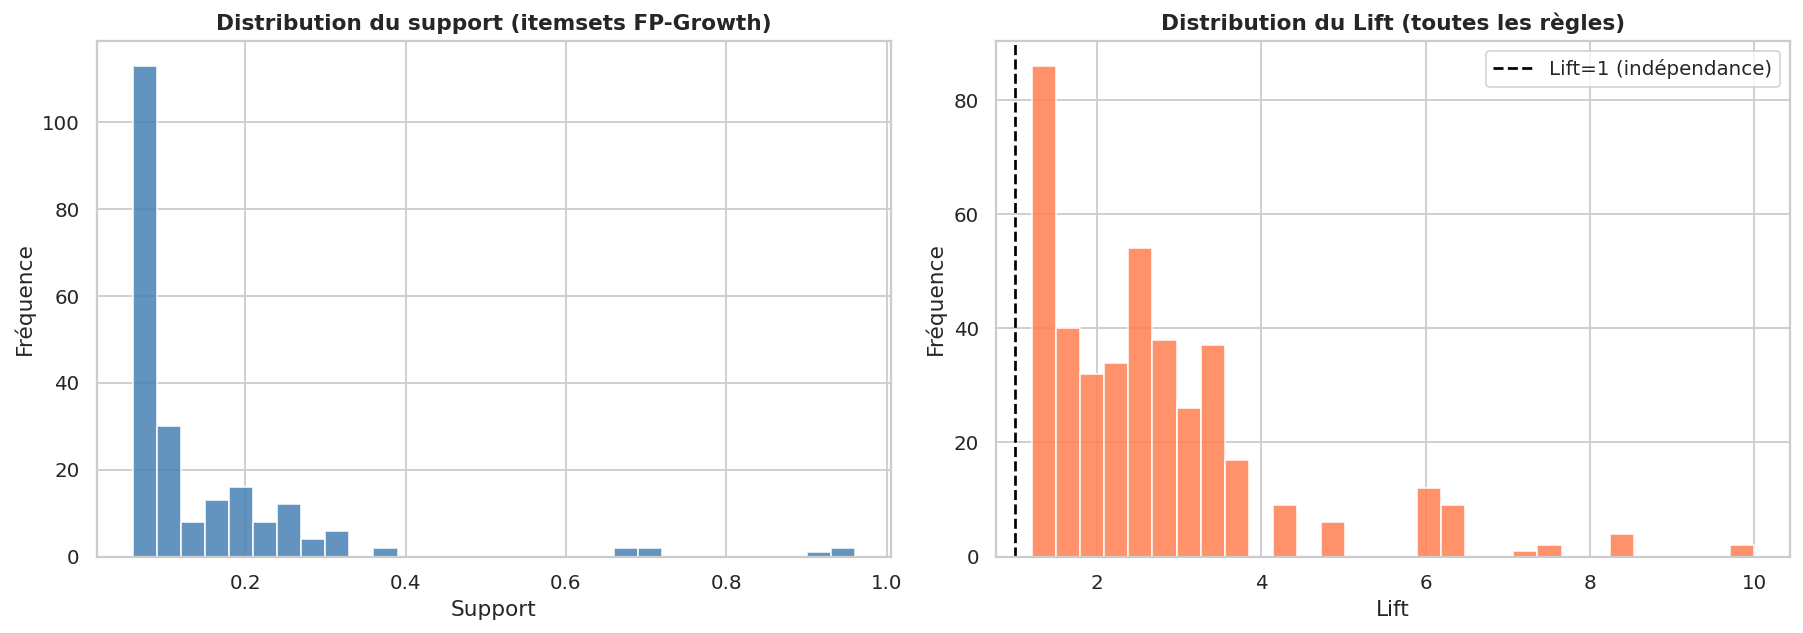

✅ phase5_distributions.png


In [22]:
# --- 7.5 Distribution du support et du lift ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(frequent_itemsets_fp['support'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution du support (itemsets FP-Growth)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Support'); axes[0].set_ylabel('Fréquence')

axes[1].hist(rules['lift'], bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='Lift=1 (indépendance)')
axes[1].set_title('Distribution du Lift (toutes les règles)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lift'); axes[1].set_ylabel('Fréquence'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase5_distributions.png')

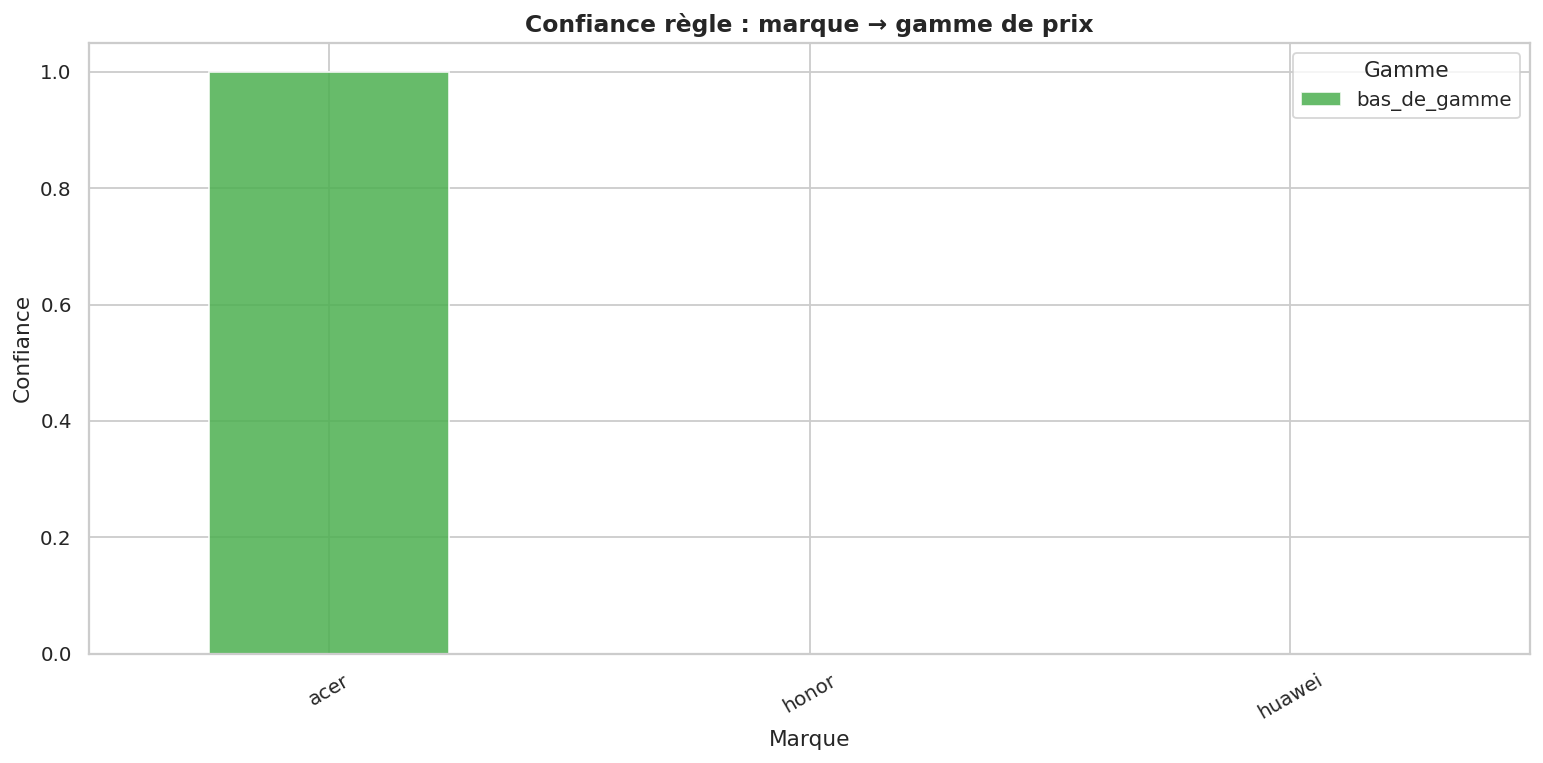

✅ phase5_brand_gamme.png


In [23]:
# --- 7.6 Confiance par marque × gamme (barplot groupé) ---
rules_brand_gamme = rules[
    (rules['antecedents'].apply(lambda x: len(x) == 1 and next(iter(x)).startswith('brand_'))) &
    (rules['consequents'].apply(lambda x: bool(x & GAMME_ITEMS)))
].copy()

if len(rules_brand_gamme) > 0:
    rules_brand_gamme['brand']     = rules_brand_gamme['antecedents_str'].str.replace('brand_', '')
    rules_brand_gamme['gamme_cons'] = rules_brand_gamme['consequents_str']

    pivot_bg = rules_brand_gamme.pivot_table(
        values='confidence', index='brand', columns='gamme_cons', aggfunc='max'
    ).fillna(0)
    gamme_order = [g for g in ['bas_de_gamme', 'milieu_de_gamme', 'haut_de_gamme']
                   if g in pivot_bg.columns]
    pivot_bg = pivot_bg[gamme_order]

    pivot_bg.plot(
        kind='bar', figsize=(12, 6),
        color=['#4CAF50', '#2196F3', '#FF5722'][:len(gamme_order)],
        alpha=0.85, edgecolor='white'
    )
    plt.title('Confiance règle : marque → gamme de prix', fontsize=13, fontweight='bold')
    plt.xlabel('Marque'); plt.ylabel('Confiance')
    plt.xticks(rotation=30); plt.legend(title='Gamme')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_brand_gamme.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ phase5_brand_gamme.png')
else:
    print('⚠ Pas de règles brand → gamme — essaie MIN_SUPPORT = 0.03')

## 8. Export

In [24]:
# --- 8.1 Export CSV de toutes les règles ---
rules_export = rules[[
    'antecedents_str', 'consequents_str', 'rule_str',
    'support', 'confidence', 'lift', 'leverage', 'conviction'
]].copy()
rules_export.to_csv(os.path.join(OUTPUT_DIR, 'association_rules.csv'), index=False, encoding='utf-8')
print(f'✅ association_rules.csv  ({len(rules_export)} règles)')

✅ association_rules.csv  (409 règles)


In [25]:
# --- 8.2 Export JSON pour Django (top 50 règles → gamme) ---
rules_json = []
for _, row in rules_gamme.head(50).iterrows():
    rules_json.append({
        'antecedents': list(row['antecedents']),
        'consequents': list(row['consequents']),
        'rule':        row['rule_str'],
        'support':     round(float(row['support']), 4),
        'confidence':  round(float(row['confidence']), 4),
        'lift':        round(float(row['lift']), 4),
    })

export_meta = {
    'params': {
        'min_support':    MIN_SUPPORT,
        'min_confidence': MIN_CONFIDENCE,
        'min_lift':       MIN_LIFT,
        'algorithm':      'FP-Growth (mlxtend)',
        'features_used':  ['brand', 'platform', 'ram_gb', 'storage_gb',
                           'cluster_kmeans_label', 'anomaly_type'],
        'note':           'rating et reviews_count exclus (supprimés Phase 1, 100% NaN)'
    },
    'stats': {
        'n_transactions':      len(df),
        'n_items':             len(te.columns_),
        'n_frequent_itemsets': len(frequent_itemsets_fp),
        'n_rules_total':       len(rules),
        'n_rules_gamme':       len(rules_gamme),
        'n_rules_anomalie':    len(rules_anomaly),
    },
    'top_rules_gamme': rules_json
}

with open(os.path.join(OUTPUT_DIR, 'association_rules.json'), 'w', encoding='utf-8') as f:
    json.dump(export_meta, f, ensure_ascii=False, indent=2)

print('✅ association_rules.json')

✅ association_rules.json


In [26]:
print('=' * 65)
print('         RÉSUMÉ — PHASE 5 TERMINÉE')
print('=' * 65)
print(f'  Algorithmes       : Apriori + FP-Growth (mlxtend)')
print(f'  Features items    : brand, platform, ram_gb, storage_gb,')
print(f'                      cluster_kmeans_label, anomaly_type')
print(f'  (rating & reviews_count exclus dès Phase 1 — 100% NaN)')
print(f'  Transactions      : {len(df)}')
print(f'  Items uniques     : {len(te.columns_)}')
print(f'  Itemsets fréquents: {len(frequent_itemsets_fp)}')
print(f'  Règles totales    : {len(rules)}')
print(f'  Règles → gamme    : {len(rules_gamme)}')
print(f'  Règles → anomalie : {len(rules_anomaly)}')
print(f'  Paramètres        : support≥{MIN_SUPPORT}, confiance≥{MIN_CONFIDENCE}, lift≥{MIN_LIFT}')
print('=' * 65)
print('  Fichiers produits :')
print('    📄 association_rules.csv         (toutes les règles)')
print('    📊 association_rules.json        (top 50 → Django)')
print('    🖼  phase5_support_confidence.png')
print('    🖼  phase5_top_rules_lift.png')
print('    🖼  phase5_heatmap_confidence.png')
print('    🖼  phase5_network_graph.png')
print('    🖼  phase5_distributions.png')
print('    🖼  phase5_brand_gamme.png')
print('=' * 65)
print('  ➡  Prochain : Phase 6 — Export final enrichi')

         RÉSUMÉ — PHASE 5 TERMINÉE
  Algorithmes       : Apriori + FP-Growth (mlxtend)
  Features items    : brand, platform, ram_gb, storage_gb,
                      cluster_kmeans_label, anomaly_type
  (rating & reviews_count exclus dès Phase 1 — 100% NaN)
  Transactions      : 50
  Items uniques     : 25
  Itemsets fréquents: 219
  Règles totales    : 409
  Règles → gamme    : 149
  Règles → anomalie : 0
  Paramètres        : support≥0.05, confiance≥0.5, lift≥1.2
  Fichiers produits :
    📄 association_rules.csv         (toutes les règles)
    📊 association_rules.json        (top 50 → Django)
    🖼  phase5_support_confidence.png
    🖼  phase5_top_rules_lift.png
    🖼  phase5_heatmap_confidence.png
    🖼  phase5_network_graph.png
    🖼  phase5_distributions.png
    🖼  phase5_brand_gamme.png
  ➡  Prochain : Phase 6 — Export final enrichi
